In [78]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

In [79]:
def u_with_noise_at_end(qc, n, theta, phi, lam, epsilon):
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)

    qc.u(theta, phi, lam, [n])
    
    qc.append(depolarizing, [n])
    
    return qc


In [80]:
# Example usage
n = 2
# Apply the U3 gate to the qubit
theta = 0.5  # rotation angle around Y axis
phi = 0.2    # rotation angle around Z axis
lam = 0.3    # rotation angle around Z axis
epsilon = 0.1  # error rate for depolarizing channel

qc = QuantumCircuit(5)
circuit = u_with_noise_at_end(qc, n, theta, phi, lam, epsilon)
print(circuit)

                                          
q_0: ─────────────────────────────────────
                                          
q_1: ─────────────────────────────────────
     ┌────────────────┐┌─────────────────┐
q_2: ┤ U(0.5,0.2,0.3) ├┤ Quantum_channel ├
     └────────────────┘└─────────────────┘
q_3: ─────────────────────────────────────
                                          
q_4: ─────────────────────────────────────
                                          


In [81]:
# Dimension of the Hilbert space
dim = 2 ** 1

# Create the identity matrix
identity_matrix = np.eye(dim)

# Create the maximally mixed state as a density matrix
maximally_mixed_state = DensityMatrix(identity_matrix / dim)

# Create a Quantum Circuit acting on a quantum register of 2 qubits
qc = QuantumCircuit(1)

qc=u_with_noise_at_end(qc, 0, theta, phi, lam, 0)

pure_state = DensityMatrix(qc)


In [82]:
def purified_rho_with_swaptest(epsilon):

    # Create a Quantum Circuit acting on a quantum register of three qubits
    qc = QuantumCircuit(3)
    
    qc=u_with_noise_at_end(qc, 1, theta, phi, lam, epsilon)
    qc=u_with_noise_at_end(qc, 2, theta, phi, lam, epsilon)
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
    qc.cswap(0, 1, 2)
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)


    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # reduced_rho_q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = reduced_rho_q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = reduced_rho_q0.data[1, 1].real  # Probability of q0 being in |1>

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)

    # Create the 3-qubit projection operator using tensor products
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(P1))

    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    
    # Trace out qubits q0, q2
    reduced_rho = partial_trace(DensityMatrix(post_meas_rho0), [0, 2])
    
    reduced_rho1 = partial_trace(state, [0, 2])
    reduced_rho2 = partial_trace(DensityMatrix(projected_rho0+projected_rho1), [0, 2])
    
    # purified_rho=prob_0*reduced_rho + prob_1*maximally_mixed_state
    purified_rho=reduced_rho 
        

    return purified_rho


In [83]:
def rho_with(epsilon):

    # Create a Quantum Circuit acting on a quantum register of 1 qubit
    qc = QuantumCircuit(1)
    
    qc=u_with_noise_at_end(qc, 0, theta, phi, lam, epsilon)
    
    state = DensityMatrix(qc)

    return state
    

In [84]:
def purified_rho_3qubits_with(epsilon,n,flag):

    list_rho_odd=[]
    list_rho_even=[]
    list_p0_odd=[]
    list_p0_even=[]
    list_p1_odd=[]
    list_p1_even=[]

    qc_odd = QuantumCircuit(4)
    qc_odd.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_odd.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
    qc_odd.cswap(0, 1, 2)
    
    # Apply the second Hadamard gate to the first qubit
    qc_odd.h(0)

    
    qc_even = QuantumCircuit(4)
    qc_even.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_even.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 1, 3)
    
    # Apply the second Hadamard gate to the first qubit
    qc_even.h(0)


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(4)
    
    qc=u_with_noise_at_end(qc, 1, theta, phi, lam, epsilon)
    qc=u_with_noise_at_end(qc, 2, theta, phi, lam, epsilon)
    qc=u_with_noise_at_end(qc, 3, theta, phi, lam, epsilon)
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
    qc.cswap(0, 1, 2)
    
   
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)


    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 4-qubit projection operator using tensor products
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_odd.append(prob_0)
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_odd.append(prob_1)
    
    # Trace out qubits q0, q1, q2
    list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2]))

    # update the state
    state=DensityMatrix(post_meas_rho0)
    # print(state)

    state=state.evolve(qc_even)
    # print(state)
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    # print(projected_rho0)
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_even.append(prob_0)
            
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    # print(projected_rho1)
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_even.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q5, and q6
    list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 3]))

    # update the state
    state=DensityMatrix(post_meas_rho0)

    
    for i in range(n-1):
            # Block A
            
            state=state.evolve(qc_odd)
            
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_odd.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_odd.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q3, and q4
            list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


            # Block B
            state=state.evolve(qc_even)
    
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_even.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_even.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q5, and q6
            list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 3]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


    

    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    
    purified_rho=list_p1_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p0_odd[0]*list_p1_even[0]*list_rho_even[0]
    
    for j in range(n-1):
        #print(j)
        product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:j+1])
        product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:j+1])
        product_list_p0=product_list_p0_odd*product_list_p0_even

        purified_rho=purified_rho+product_list_p0*list_p1_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p0*list_p0_odd[j+1]*list_p1_even[j+1]*list_rho_even[j+1]

    product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:n])
    product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:n])
    product_list_p0=product_list_p0_odd*product_list_p0_even

    if flag > 0:
        # purified_rho=partial_trace(state, [0, 1, 2])
        # purified_rho=partial_trace(state, [0, 1, 3])
        purified_rho=partial_trace(state, [0, 2, 3])
    else:
        purified_rho=purified_rho+product_list_p0*partial_trace(state, [0, 1, 2])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)


In [85]:
list_of_epsilon=[i * 0.1 for i in range(11)]

list_of_purified_fidelity_swap=[]
for i in list_of_epsilon:
    list_of_purified_fidelity_swap.append(state_fidelity(purified_rho_with_swaptest(i), pure_state))

rows, cols = 2, 0
value = 0
list_of_purified_fidelity= [[value] * cols for _ in range(rows)]
list_of_fidelity=[]
for i in list_of_epsilon:
    for j in range(rows):
        list_of_purified_fidelity[j].append(state_fidelity(purified_rho_3qubits_with(i,10**j,1), pure_state))
    
    list_of_fidelity.append(state_fidelity(rho_with(i), pure_state))


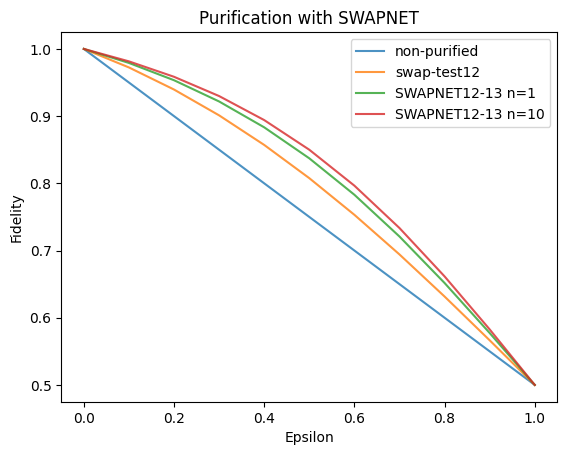

In [86]:
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified', alpha=0.8)
plt.plot(list_of_epsilon,list_of_purified_fidelity_swap,label='swap-test12', alpha=0.8)
for i in range(rows):
    plt.plot(list_of_epsilon,list_of_purified_fidelity[i],label='SWAPNET12-13 n='+str(10**i), alpha=0.8)
    
plt.title("Purification with SWAPNET")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()

In [87]:
list_of_purified_fidelity_flag0=[]
list_of_purified_fidelity_flag1=[]
list_of_purified_fidelity_flag0_n1=[]
list_of_purified_fidelity_flag1_n1=[]

for i in list_of_epsilon:
    list_of_purified_fidelity_flag0_n1.append(state_fidelity(purified_rho_3qubits_with(i,1,0), pure_state))
    list_of_purified_fidelity_flag1_n1.append(state_fidelity(purified_rho_3qubits_with(i,1,1), pure_state))
    list_of_purified_fidelity_flag0.append(state_fidelity(purified_rho_3qubits_with(i,2,0), pure_state))
    list_of_purified_fidelity_flag1.append(state_fidelity(purified_rho_3qubits_with(i,2,1), pure_state))


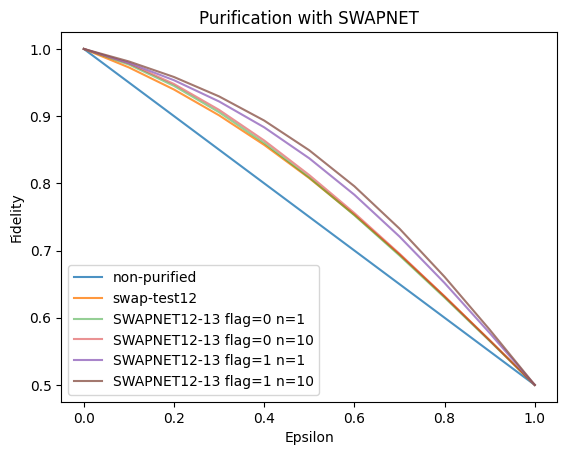

In [88]:
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified', alpha=0.8)
plt.plot(list_of_epsilon,list_of_purified_fidelity_swap,label='swap-test12', alpha=0.8)

plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5)
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0,label='SWAPNET12-13 flag=0 n='+str(10), alpha=0.5)
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1_n1,label='SWAPNET12-13 flag=1 n='+str(1), alpha=0.8)
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1,label='SWAPNET12-13 flag=1 n='+str(10), alpha=0.8)


    
plt.title("Purification with SWAPNET")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()